In [1]:
import torch
import torch.nn as nn

from source.runge_preprocessing import y_train, x_train_scaled, ETA_VALUES, LAMBDA_VALUES, x_train_scaled, y_train, x_test, y_test, x, y
import source.activation_functions as activation_functions
from source.cost_functions import mse
from source.utils import neural_network_loop, create_activations_layderdim, pytorch_loop
from source.neural_network import NN
from source.plotting import plot_heatmap, plot_runges


# Common settings for this task



In [2]:
ITERATIONS = 100
MOMENTUM = 0.9
VERBOSE = False
SHOW_PLOT = True
SAVE_FIGURE = True
OPTIMIZER = 'SGD'


# Pytorch with FFNN

Using data from runge_preprocessing


In [3]:
# Defining Pytorch model

# Convert to Pytorch tensors
x_train_scaled_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# ReLU activation function and (50, 100) hidden layer
model= nn.Sequential(
            nn.Linear(1,50),
            nn.ReLU(),
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )

cost = nn.MSELoss()

In [4]:
# Pytorch
result_torch = pytorch_loop(model, cost, ETA_VALUES, LAMBDA_VALUES, OPTIMIZER, ITERATIONS, x_train_scaled_tensor, y_train_tensor, 
                            x_test_tensor, y_test_tensor, momentum_val=MOMENTUM, verbose=False)



Epoch 0, Loss: 0.242633
Epoch 0, Loss: 0.067007
Epoch 0, Loss: 0.067350
Epoch 0, Loss: 0.066905
Epoch 0, Loss: 0.065903
Epoch 0, Loss: 0.063247
Epoch 0, Loss: 0.041759
Epoch 0, Loss: 0.016399
Epoch 0, Loss: 0.013015
Epoch 0, Loss: 0.012186
Epoch 0, Loss: 0.011348
Epoch 0, Loss: 0.009712
Epoch 0, Loss: 0.009693
Epoch 0, Loss: 0.009674
Epoch 0, Loss: 0.009656
Epoch 0, Loss: 0.009637
Epoch 0, Loss: 0.009622
Epoch 0, Loss: 0.009605
Epoch 0, Loss: 0.009594
Epoch 0, Loss: 0.009584
Epoch 0, Loss: 0.009575
Epoch 0, Loss: 0.009573
Epoch 0, Loss: 0.009572
Epoch 0, Loss: 0.009571
Epoch 0, Loss: 0.009570
Epoch 0, Loss: 0.009569
Epoch 0, Loss: 0.009568
Epoch 0, Loss: 0.009567
Epoch 0, Loss: 0.009566
Epoch 0, Loss: 0.009565
Epoch 0, Loss: 0.009564
Epoch 0, Loss: 0.009564
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0.009563
Epoch 0, Loss: 0

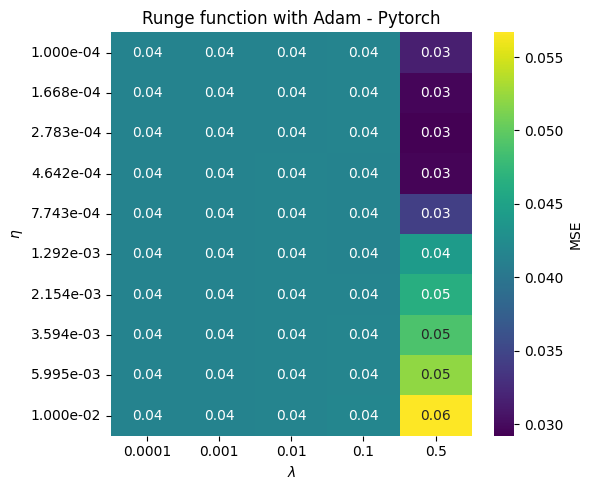

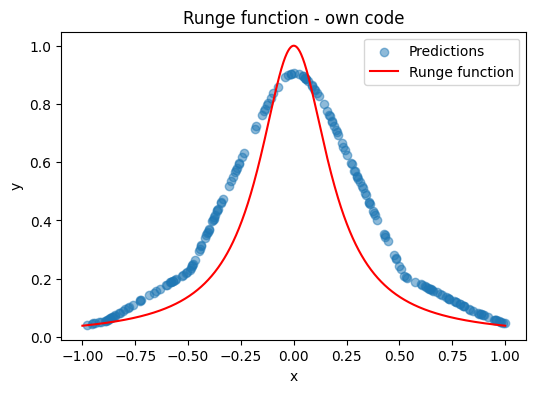

In [5]:
# Plotting heatmaps - Pytorch

plot_heatmap(result_torch, title='Runge function with Adam - Pytorch', heat_metric='MSE', filename=f'part_c-heatmap_pytorch', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# Runges
min_row = result_torch.loc[result_torch['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - own code', filename=f'part_c-runges_pytorch', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# Own implementation

In [ ]:
# Settings for own implementation

# Activation output always linear with regression
ACTIVATION_FUNCTION_OUTPUT = activation_functions.linear
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = activation_functions.linear_derivative

# Hidden layers
ACTIVATION_FUNCTION = activation_functions.RELU
ACTIVATION_FUNCTION_DERIVATIVE = activation_functions.RELU_derivative
RUNGE_HIDDEN = (50, 100)

# Generate list of activation functions, and dimensions of layers
activations, activations_derivative, _dim = create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, ACTIVATION_FUNCTION_OUTPUT, ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE, RUNGE_HIDDEN, y_train, x_train_scaled)


In [7]:
# Compute own FFNN

runge_NN = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)
result_own = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, OPTIMIZER, ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=True)



Training with: optimizer=SGD, lr=0.5, lambda=0.01, iteration=100
Using scheduler: momentum with Eta=0.5


c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\cost_functions.py:22: RuntimeWarning: overflow encountered in square
  return np.mean(diff ** 2)
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:268: RuntimeWarning: overflow encountered in matmul
  gradient_weights = layer_input.T @ dC_dz
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:262: RuntimeWarning: overflow encountered in matmul
  dC_da = dC_dz @ W.T
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:265: RuntimeWarning: invalid value encountered in multiply
  dC_dz = dC_da * activation_der(z)
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:268: RuntimeWarning: invalid value encountered in matmul
  gradient_weights = layer_input.T @ dC_dz
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py


Training with: optimizer=SGD, lr=0.5, lambda=0.005994842503189409, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SGD, lr=0.5, lambda=0.003593813663804626, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SGD, lr=0.5, lambda=0.0021544346900318843, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SGD, lr=0.5, lambda=0.001291549665014884, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SGD, lr=0.5, lambda=0.000774263682681127, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SGD, lr=0.5, lambda=0.0004641588833612782, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SGD, lr=0.5, lambda=0.0002782559402207126, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SGD, lr=0.5, lambda=0.0001668100537200059, iteration=100
Using scheduler: momentum with Eta=0.5

Training with: optimizer=SG

ValueError: zero-size array to reduction operation fmin which has no identity

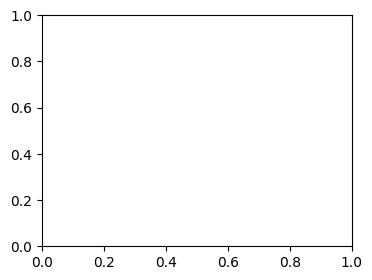

In [8]:
# Plotting heatmaps - own code

plot_heatmap(result_own, title='Runge function with Adam - Pytorch', heat_metric='MSE', filename=f'part_c-heatmap_own_code', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# Runges
min_row = result_own.loc[result_own['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - own code', filename=f'part_c-runges_own_code', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)


# Comparing gradients from own implementation and autograd

In [ ]:
# custom imports
from source.neural_network import NN

In [ ]:
import source.schedulers as schedulers
from source.runge_preprocessing import x_test, y_test

runge_NN = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)
runge_NN.compare_gradients(X = x_train_scaled, targets = y_train)

